In [1]:
import json
import sys
sys.path.insert(0, "..")

import pandas as pd
import config
from src.db_io import leer_tabla_sqlite

df = leer_tabla_sqlite(config.ORO_DB, "cliente_features")
resumen = {
    "n_filas": len(df),
    "n_columnas": df.shape[1],
    "nulos_por_columna": df.isnull().sum().to_dict(),
}
(config.OUTPUTS_DIR / "eda").mkdir(parents=True, exist_ok=True)
with open(config.OUTPUTS_DIR / "eda" / "resumen_shape.json", "w") as f:
    json.dump({k: v for k, v in resumen.items() if k != "nulos_por_columna"} |
              {"nulos_por_columna": {k: int(v) for k, v in resumen["nulos_por_columna"].items()}}, f, indent=2)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
numero_id,860223.0,NaN,NaN,NaN,11296873133658780.0,5324473300252032000.0,-9223363218022227968.0,-4595761860927589376.0,19608476502043612.0,4615083692997420032.0,9223362823850479616.0
grupo_edad,860223,5,36-49,236761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_genero,860130,4,femenino,472622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_segmento,860223,3,personal,645970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_tipo_de_vivienda,268532,4,FAMILIAR,129359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingresos_mensuales,859974.0,NaN,NaN,NaN,39323399.423105,16996810764.786861,0.0,1300000.0,2000000.0,4889761.0,9000008796700.0
total_egresos_mensuales,859974.0,NaN,NaN,NaN,147802254.445673,26467249667.784256,0.0,100000.0,400000.0,800000.0,8500000850000.0
total_activos,859974.0,NaN,NaN,NaN,199791900.929992,21327494822.675026,0.0,1145000.0,10902000.0,66937000.0,9041914166666.0
total_pasivos,859974.0,NaN,NaN,NaN,96877622.455026,22461172114.029453,0.0,0.0,0.0,1.0,9000012000000.0
total_patrimonio,859963.0,NaN,NaN,NaN,131116804.171393,26894795137.145702,-8999512000000.0,153641.0,7000000.0,47350000.0,9041902166666.0


,variable,categoria,tasa_adopcion,n_clientes
0,grupo_edad,18-25,0.034031,110400
1,grupo_edad,26-35,0.078648,212490
2,grupo_edad,36-49,0.097685,236761
3,grupo_edad,50-65,0.082134,163234
4,grupo_edad,65+,0.046520,137338
5,desc_genero,femenino,0.085739,472622
6,desc_genero,masculino,0.059027,387430
7,desc_genero,no binario,0.044444,45
8,desc_genero,trans,0.000000,33
9,desc_genero,NaN,0.000000,93


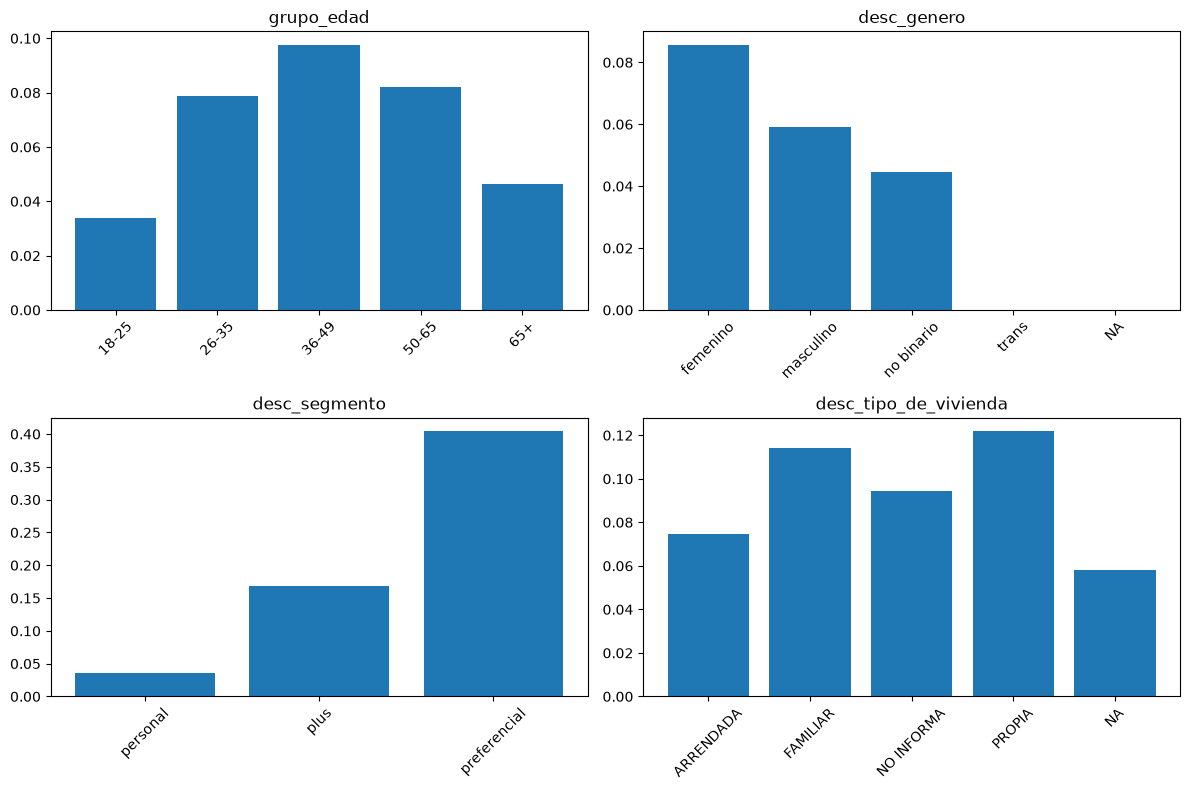

In [2]:
import matplotlib.pyplot as plt

sensibles = ["grupo_edad", "desc_genero", "desc_segmento", "desc_tipo_de_vivienda"]
tablas = []
for col in sensibles:
    t = df.groupby(col, dropna=False)["etiqueta_adopcion"].agg(["mean", "count"]).reset_index()
    t.insert(0, "variable", col)
    t = t.rename(columns={col: "categoria", "mean": "tasa_adopcion", "count": "n_clientes"})
    tablas.append(t)

resumen_sensibles = pd.concat(tablas, ignore_index=True)
resumen_sensibles.to_csv(config.OUTPUTS_DIR / "eda" / "tasas_adopcion_por_segmento.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, sensibles):
    subset = resumen_sensibles[resumen_sensibles["variable"] == col]
    ax.bar(subset["categoria"].fillna("NA").astype(str), subset["tasa_adopcion"])
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda" / "tasas_adopcion_por_segmento.png")

resumen_sensibles